# 📱 Mobile Money Transaction Anonymizer
**DS Data Collection Spring26**

Processes raw OrangeMoney / MobileMoney (MTN MoMo) SMS exports into clean, anonymized transaction datasets.

### Pipeline:
1. Load your raw Excel file
2. Detect operator (OrangeMoney / MobileMoney)
3. Filter to money-moving messages only (balance change indicator)
4. Extract: transaction type, direction, amount, currency, new balance
5. Anonymize: user name & phone → userId; other names & phones → hashed tokens
6. Export clean anonymized file

**Supported languages:** French & English (Cameroonian bilingual context)
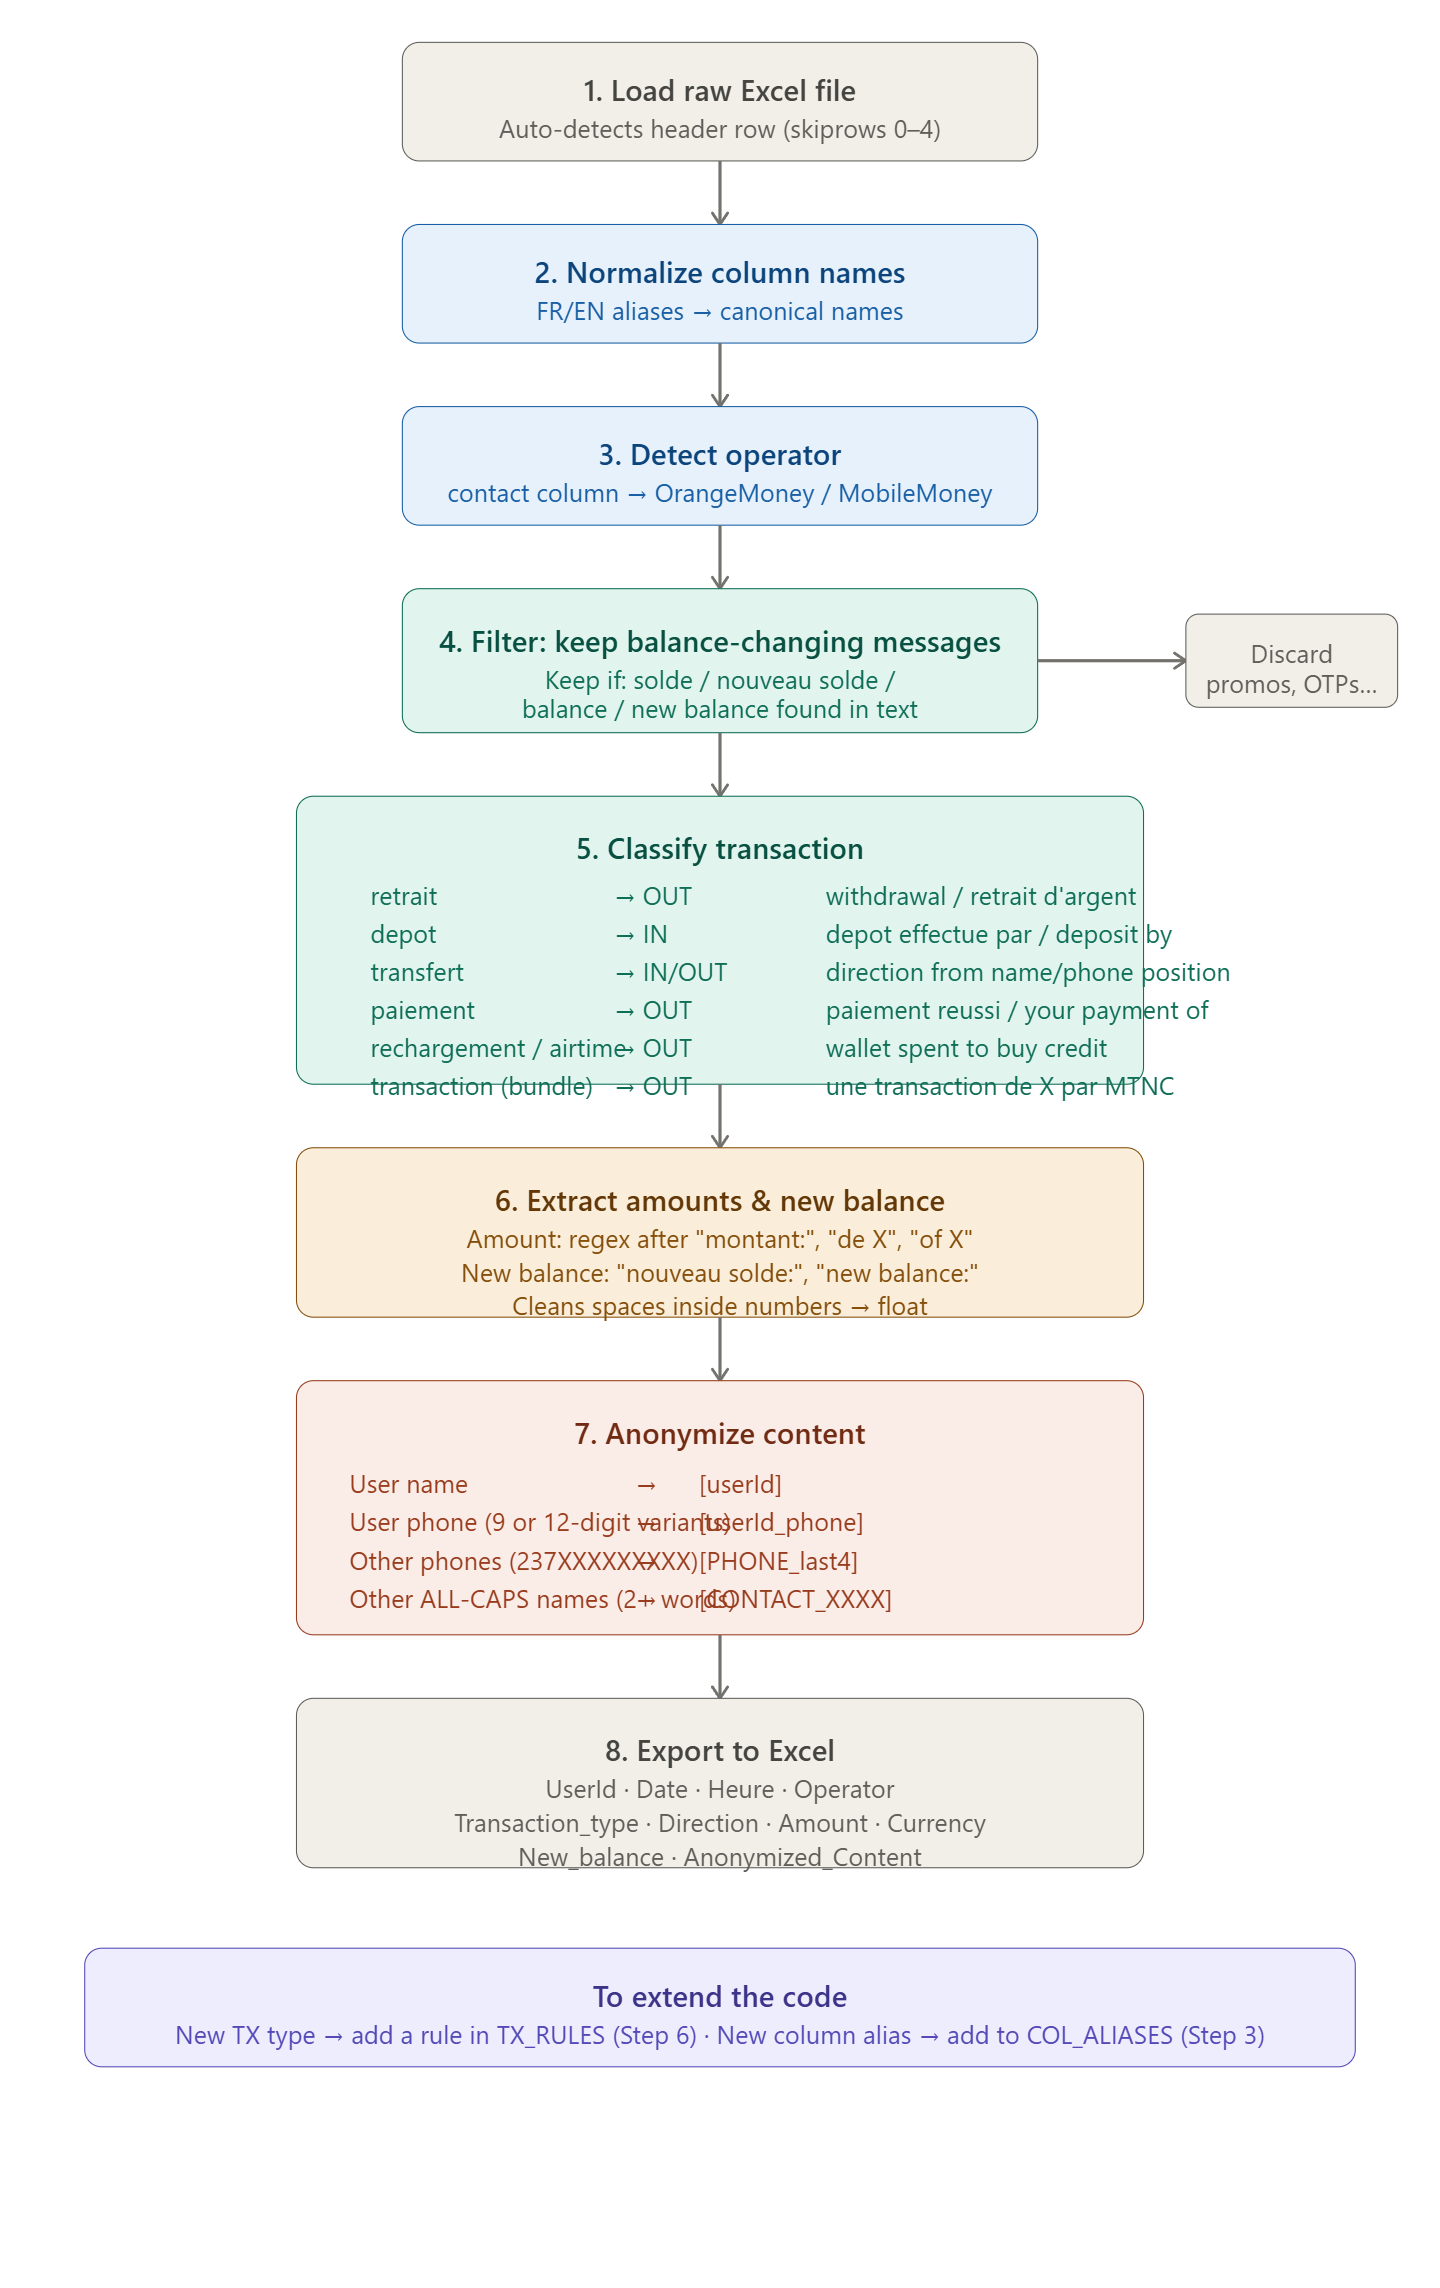

## ⚙️ Step 1 — Install & imports

In [1]:
!pip install openpyxl
import re
import hashlib
import pandas as pd
from pathlib import Path
print('✅ Ready!')

✅ Ready!


In [2]:
import os
os.chdir("D:\BenLearning\Mes Formations\COURSES ICT UNIVERSITY\Spring 2026\Intro to datascience\DataSet")
%pwd

'D:\\BenLearning\\Mes Formations\\COURSES ICT UNIVERSITY\\Spring 2026\\Intro to datascience\\DataSet'

## 🔧 Step 2 — Configuration  ← Edit this cell

In [19]:
# ─────────────────────────────────────────────────────────────
# INPUT FILE — path to the student's raw Excel export
INPUT_FILE = r"Messages with MobileMoney 2026-04-06 043141.xlsx" #'/content/drive/MyDrive/YOUR_FILE.xlsx'

# USER IDENTITY — used for anonymization
USER_FULL_NAME = 'FOTSING KUETCHE'    # exact name as it appears in messages (can be partial)
USER_PHONE     = '654253860'          # phone number as it appears in messages (9 or 12 digits)
USER_ID        = 'user001'            # anonymized ID to replace name & phone

# OUTPUT FILE
OUTPUT_FILE = f'{USER_ID}_transactions_2.xlsx'
OUTPUT_FILE_CSV = f'{USER_ID}_transactions_2.csv'
# ─────────────────────────────────────────────────────────────

assert os.path.isfile(INPUT_FILE), f'❌ File not found: {INPUT_FILE}'
print(f'✅ Config OK — processing file for user: {USER_ID}')

✅ Config OK — processing file for user: user001


## 📖 Step 3 — Load & normalize the raw file

In [20]:
# ── Column name aliases (FR / EN) ─────────────────────────────
COL_ALIASES = {
    'date':      ['date'],
    'heure':     ['heure', 'time'],
    'direction': ['direction'],
    'contact':   ['contact'],
    'telephone': ['téléphone', 'telephone', 'phone'],
    'contenu':   ['contenu', 'content'],
    'type':      ['type'],
}

def normalize_columns(df):
    """Remap any FR or EN column names to canonical lowercase names."""
    rename = {}
    for canonical, aliases in COL_ALIASES.items():
        for col in df.columns:
            if str(col).strip().lower() in aliases:
                rename[col] = canonical
                break
    return df.rename(columns=rename)

def load_file(path):
    """
    Load an OrangeMoney or MobileMoney Excel export.
    Auto-detects the header row (OrangeMoney has 3 metadata rows at top).
    """
    # Try skiprows 0, 1, 2, 3 until we get the real columns
    for skip in range(5):
        df = pd.read_excel(path, skiprows=skip)
        cols_lower = [str(c).strip().lower() for c in df.columns]
        if any(c in cols_lower for c in ['date', 'contenu', 'content']):
            df = normalize_columns(df)
            df = df.dropna(subset=['contenu'], how='all')
            df['contenu'] = df['contenu'].astype(str).str.replace('_x000d_', ' ', regex=False).str.strip()
            print(f'✅ Loaded {len(df)} rows (skipped {skip} header rows)')
            print(f'   Columns: {df.columns.tolist()}')
            return df
    raise ValueError('Could not detect column headers — check the file format.')

df_raw = load_file(INPUT_FILE)
df_raw.head(3)

✅ Loaded 108 rows (skipped 0 header rows)
   Columns: ['date', 'heure', 'direction', 'contact', 'telephone', 'contenu', 'type']


,date,heure,direction,contact,telephone,contenu,type
0,2025-02-21,16:42:42,Received,MobileMoney,MobileMoney,Yello you have received 150 XAF Airtime from 237652790841 - NELLY BERINYUY SENDZE with transaction Id: 11648814045. ...,SMS
1,2025-03-10,07:04:00,Received,MobileMoney,MobileMoney,Your account (FRI:75923491/MM) has been set to passive state due to inactivity,SMS
2,2025-04-27,04:48:07,Received,MobileMoney,MobileMoney,"Hello, the transaction with amount 500 XAF for MTNC BUNDLES_FORFAITS (MTN_Bundles) with message: failed at 2025-0...",SMS


## 🏦 Step 4 — Detect operator

In [21]:
def detect_operator(df):
    """
    Detect OrangeMoney or MobileMoney from the contact/telephone column.
    Returns 'OrangeMoney', 'MobileMoney', or 'Unknown'.
    """
    # Check contact or telephone columns
    for col in ['contact', 'telephone']:
        if col in df.columns:
            sample = df[col].dropna().astype(str).str.lower()
            if sample.str.contains('orangemoney').any():
                return 'OrangeMoney'
            if sample.str.contains('mobilemoney').any():
                return 'MobileMoney'
    return 'Unknown'

OPERATOR = detect_operator(df_raw)
print(f'✅ Operator detected: {OPERATOR}')

✅ Operator detected: MobileMoney


## 🔍 Step 5 — Filter: keep only balance-changing messages

In [22]:
# Keywords that indicate a balance change occurred (FR + EN)
BALANCE_KEYWORDS = [
    # French
    'nouveau solde', 'nouveau solde est', #'solde', 
    # English
    'new balance', 'your new balance',#'balance', 
]

BALANCE_RE = re.compile(
    r'(?:' + '|'.join(re.escape(k) for k in BALANCE_KEYWORDS) + r')',
    re.IGNORECASE
)

mask = df_raw['contenu'].apply(lambda x: bool(BALANCE_RE.search(str(x))))
df_filtered = df_raw[mask].copy().reset_index(drop=True)

print(f'📊 Total messages      : {len(df_raw)}')
print(f'✅ Balance-related     : {len(df_filtered)}')
print(f'🗑️  Discarded (no balance): {len(df_raw) - len(df_filtered)}')

📊 Total messages      : 108
✅ Balance-related     : 57
🗑️  Discarded (no balance): 51


## 🧠 Step 6 — Extract transaction type, direction, amount, new balance

In [23]:
# ── Amount & balance patterns ─────────────────────────────────
# Matches: 1200 FCFA / 1 200 FCFA / 1200XAF / 1200.50 FCFA
AMOUNT_RE = re.compile(
    r'(?:montant[^:]*:\s*|(?<!solde\sest\s)de\s+|amount\s+|of\s+)'
    r'(\d[\d\s,\.]*?)\s*(FCFA|XAF)',
    re.IGNORECASE
)

AMOUNT_FALLBACK_RE = re.compile(
    r'(\d[\d\s]*?)\s*(FCFA|XAF)',
    re.IGNORECASE
)

# BALANCE_VAL_RE = re.compile(
#     r'(?:nouveau\s+solde[^:]*:|new\s+balance[^:]*:|votre\s+nouveau\s+solde[^:]*:|'
#     r'nouveau\s+solde\s+est\s+de\s*:|nouveau\s+solde\s+est\s+de\s*|solde\s*:)\s*'
#     r'(\d[\d\s,\.]*?)\s*(FCFA|XAF)',
#     re.IGNORECASE
# )
BALANCE_VAL_RE = re.compile(
    r'(?:'
        r'votre\s+nouveau\s+solde\s+est\s+de\s+|your\s+new\s+balance\s+is\s+|' # Full sentences
        r'nouveau\s+solde\s+est\s+de\s*:?|new\s+balance\s+is\s*:?|'             # Short sentences
        r'nouveau\s+solde\s+est\s*:?|new\s+balance\s+is\s*:?|'  
        r'nouveau\s+solde\s*:?|new\s+balance\s*:?|'                        # Labels
        r'solde\s*:?|balance\s*:?'                      # Other variants
    r')\s*'
    r'(\d[\d\s,\.]*?)\s*(FCFA|XAF)',
    re.IGNORECASE
)


def clean_amount(raw):
    """Remove spaces and commas inside a number string, return float."""
    if raw is None:
        return None
    cleaned = re.sub(r'[\s,]', '', str(raw))
    try:
        return float(cleaned)
    except ValueError:
        return None

def extract_amount(text):
    """Extract the transaction amount and currency."""
    m = AMOUNT_RE.search(text)
    if m:
        return clean_amount(m.group(1)), m.group(2).upper()
    # Fallback: first numeric+currency in message
    m = AMOUNT_FALLBACK_RE.search(text)
    if m:
        return clean_amount(m.group(1)), m.group(2).upper()
    return None, None

def extract_new_balance(text):
    """Extract the new balance value and currency."""
    m = BALANCE_VAL_RE.search(text)
    if m:
        return clean_amount(m.group(1)), m.group(2).upper()
    return None, None

print('✅ Amount & balance extractors ready!')

✅ Amount & balance extractors ready!


In [24]:
# ── Transaction type & direction rules ───────────────────────
#
# Each rule: (tx_type, direction, [patterns...])
# Patterns are matched case-insensitively against the message.
# Rules are evaluated IN ORDER — first match wins.
#
# Direction logic:
#   OUT = user's wallet balance DECREASES (spending)
#   IN  = user's wallet balance INCREASES (receiving)

TX_RULES = [

    # ── RETRAIT / WITHDRAWAL ─────────────────────────────────
    # FR: retrait d'argent reussi / retrait de X FCFA de votre compte
    # EN: withdrawal successful
    ('retrait', 'OUT', [
        r"retrait\s+d'argent",
        r'retrait\s+de\s+\d',
        r'vous\s+avez\s+effectue\s+avec\s+succes\s+le\s+retrait',
        r'withdrawal\s+successful',
        r'cash\s+out',
    ]),

    # ── DEPOT / DEPOSIT (incoming cash at agent) ─────────────
    # FR: Depot effectue par X to USER
    # EN: deposit made by X to USER
    ('depot', 'IN', [
        r'depot\s+effectue\s+par',
        r'deposit\s+made\s+by',
        r'deposit\s+to\s+your',
    ]),

    # ── TRANSFERT IN (received from another person) ───────────
    # Orange FR: Transfert de OTHER vers USER reussi
    # MoMo FR:   Vous avez recu X XAF de NAME
    # MoMo EN:   You have received X XAF from NAME
    # MoMo EN:   An adjustment has been made and X XAF has been added
    ('transfert', 'IN', [
        r'(transfert|transfer).*?(frais|fees?)\s*(:|(de)|was|is)?\s*0\s*(xaf|fcfa)',  # transfer with no fees = deposit
        r'vous\s+avez\s+re[cç]u\s+\d',
        r'you\s+have\s+received\s+\d',
        r'has\s+been\s+added\s+to\s+your',
        r'adjustment\s+has\s+been\s+made',
    ]),

    # ── TRANSFERT OUT (sent to another person) ────────────────
    # Orange FR: Transfert de USER vers OTHER reussi
    # MoMo FR:   Transfert de X FCFA effectue avec succes a NAME
    # MoMo EN:   Transfer of X XAF successfully made to NAME
    ('transfert', 'OUT', [
        r'transfert\s+de\s+\d+\s*(fcfa|xaf)',
        r'transfert\s+de\s+\d+fcfa',
        r'transfer\s+of\s+\d',
        r'transfert.*effectue.*succes.*\d',
        r'transfert.*vers\s+\d',          # Orange: Transfert de USER vers PHONE
    ]),

    # ── PAIEMENT FACTURE / BILL PAYMENT ──────────────────────
    # Orange FR: paiement de votre facture ENEO de X FCFA
    # MoMo FR:   Votre paiement de X XAF a ENEO
    # MoMo EN:   Your payment of X XAF to ENEO
    ('paiement', 'OUT', [
        r'paiement\s+de\s+votre\s+facture',
        r'paiement\s+de\s+votre\s+facture',
        r'votre\s+paiement\s+de\s+\d',
        r'your\s+payment\s+of\s+\d',
        r'paiement.*réussi',
        r'payment.*successful',
        r'paiement\s+total',
        r'vous\s+venez\s+d.effectuer\s+un\s+paiement',
    ]),

    # ── RECHARGEMENT / TOP-UP (buying credit with wallet) ─────
    # Orange FR: Rechargement reussi. Montant de la transaction: X FCFA
    # EN: Top-up successful
    ('rechargement', 'OUT', [
        r'rechargement\s+reussi',
        r'top.?up\s+successful',
        r'recharge\s+successful',
    ]),

    # ── AIRTIME (buying airtime with wallet) ──────────────────
    # MoMo FR: Vous avez achete avec succes X XAF airtime
    # MoMo FR: Votre paiement de X XAF a MTNC AIRTIME
    # MoMo EN: Yello you have received X XAF Airtime from SWITCHN (airtime IN from merchant)
    #          → still OUT because wallet balance decreases (merchant charges wallet)
    ('airtime', 'OUT', [
        r'achete\s+avec\s+succes.*airtime',
        r'airtime.*transaction',
        r'paiement.*airtime',
        r'paiement.*de',
        r'payment.*airtime',
        r'you\s+have\s+received.*airtime\s+from',   # received airtime (not cash) — wallet debited
        r'vous\s+avez\s+re[cç]u.*airtime\s+de',
        r'recu.*xaf\s+airtime',
        r'received.*xaf\s+airtime',
    ]),

    # ── TRANSACTION (bundle / service debit) ─────────────────
    # MoMo FR: Une transaction de X XAF effectuee par MTNC BUNDLES
    # EN: A transaction of X XAF by MTNC BUNDLES
    ('transaction', 'OUT', [
        r'une\s+transaction\s+de\s+\d',
        r'a\s+transaction\s+of\s+\d',
        r'transaction.*effectuee\s+par',
        r'transaction.*made\s+by',
    ]),
]

# Pre-compile all patterns
TX_RULES_COMPILED = [
    (tx_type, direction, [re.compile(p, re.IGNORECASE) for p in patterns])
    for tx_type, direction, patterns in TX_RULES
]

def classify_transaction(text):
    """Return (tx_type, direction) for a message. First rule match wins."""
    for tx_type, direction, compiled_patterns in TX_RULES_COMPILED:
        for pattern in compiled_patterns:
            if pattern.search(text):
                return tx_type, direction
    return 'autre', 'unknown'

print('✅ Transaction classification rules ready!')

✅ Transaction classification rules ready!


## 🔒 Step 7 — Anonymization engine

In [25]:
# ─────────────────────────────────────────────────────────────
# Utility: short hash for anonymized tokens
# ─────────────────────────────────────────────────────────────
def short_hash(value, length=4):
    """Return a short uppercase hex hash of a string."""
    return hashlib.md5(str(value).encode()).hexdigest()[:length].upper()


# ─────────────────────────────────────────────────────────────
# Phone pattern: supports 9 to 12 digits
# Examples:
#   690942612
#   237690942612
# ─────────────────────────────────────────────────────────────
PHONE_RE = re.compile(r'\b\d{9,12}\b')


# ─────────────────────────────────────────────────────────────
# Name AFTER phone (MAIN CASE)
# Handles:
#   237690942612 JOHN DOE
#   690942612 - JOHN DOE
#   690942612: JOHN DOE
#   690942612    JOHN DOE
#   690942612–JOHN DOE
# ─────────────────────────────────────────────────────────────
NAME_AFTER_PHONE_RE = re.compile(
    r'\b(\d{9,12})\s*[-–:]?\s*([A-ZÀÂÉÈÊËÎÏÔÙÛÜÇ]{2,}(?:\s+[A-ZÀÂÉÈÊËÎÏÔÙÛÜÇ]{2,}){0,3})\b'
)


# ─────────────────────────────────────────────────────────────
# Name BEFORE phone (secondary case)
# Handles:
#   JOHN DOE (237690942612)
# ─────────────────────────────────────────────────────────────
NAME_BEFORE_PHONE_RE = re.compile(
    r'\b([A-ZÀÂÉÈÊËÎÏÔÙÛÜÇ]{2,}(?:\s+[A-ZÀÂÉÈÊËÎÏÔÙÛÜÇ]{2,}){0,3})\s*\((\d{9,12})\)'
)


# Names in MoMo withdrawal messages come after keyword like 'at'
WITHDRAWAL_NAME_RE = re.compile(
    r'\b(?:withdrawn|withdraw|retrait)\b.*?\b(?:chez|at)\s*[:\-–]?\s*([A-ZÀÂÉÈÊËÎÏÔÙÛÜÇ]{2,}(?:\s+[A-ZÀÂÉÈÊËÎÏÔÙÛÜÇ]{2,}){0,4})\b',
    re.IGNORECASE
)

# ─────────────────────────────────────────────────────────────
# Generate possible variants of user's phone
# (local vs international format)
# ─────────────────────────────────────────────────────────────
def _phone_variants(phone):
    if not phone:
        return []

    phone = str(phone).strip()
    variants = {phone}

    # Local → add country code
    if re.match(r'^6\d{8}$', phone):
        variants.add('237' + phone)

    # International → remove country code
    if re.match(r'^237\d{9}$', phone):
        variants.add(phone[3:])

    return list(variants)


# ─────────────────────────────────────────────────────────────
# Main anonymization function
# ─────────────────────────────────────────────────────────────
def anonymize_message(text, user_name=None, user_phone=None, user_id="USER"):
    """
    Replace PII in a message:

    - User's name        → [USER_ID]
    - User's phone       → [USER_ID_phone]
    - Other names        → [CONTACT_XXXX]
    - Other phones       → [PHONE_XXXX]

    IMPORTANT:
    Order of operations is critical.
    """

    result = text

    # ─────────────────────────────────────────────
    # 1. Replace USER NAME first
    # ─────────────────────────────────────────────
    if user_name and user_name.strip():
        result = re.sub(
            re.escape(user_name.strip()),
            f'[{user_id}]',
            result,
            flags=re.IGNORECASE
        )
        
    def replace_withdrawal_name(m):
        name = m.group(1).strip()
        token = short_hash(name)
        return m.group(0).replace(name, f'[CONTACT_{token}]')
    
    # ─────────────────────────────────────────────
    # 2. Replace withdrawal names (chez / at)
    # ─────────────────────────────────────────────
    result = WITHDRAWAL_NAME_RE.sub(replace_withdrawal_name, result)

    # ─────────────────────────────────────────────
    # 2. Replace NAMES AFTER PHONE (CRITICAL STEP)
    # Must happen BEFORE phone masking
    # ─────────────────────────────────────────────
    def replace_name_after(m):
        phone = m.group(1)
        name = m.group(2).strip()

        token = short_hash(name)
        return f'{phone} [CONTACT_{token}]'

    result = NAME_AFTER_PHONE_RE.sub(replace_name_after, result)

    # ─────────────────────────────────────────────
    # 3. Replace NAMES BEFORE PHONE
    # ─────────────────────────────────────────────
    def replace_name_before(m):
        name = m.group(1).strip()
        phone = m.group(2)

        token = short_hash(name)
        return f'[CONTACT_{token}] ({phone})'

    result = NAME_BEFORE_PHONE_RE.sub(replace_name_before, result)

    # ─────────────────────────────────────────────
    # 4. Replace USER PHONE
    # ─────────────────────────────────────────────
    for variant in _phone_variants(user_phone):
        result = result.replace(variant, f'[{user_id}_phone]')

    # ─────────────────────────────────────────────
    # 5. Replace ALL remaining phones
    # ─────────────────────────────────────────────
    def replace_phone(m):
        phone = m.group(0)
        return f'[PHONE_{phone[-4:]}]'

    result = PHONE_RE.sub(replace_phone, result)

    # ─────────────────────────────────────────────
    # 6. Replace remaining ALL-CAPS names
    # (fallback detection)
    # ─────────────────────────────────────────────
    skip_tokens = {
        'FCFA', 'XAF', 'SMS', 'ID', 'MTN', 'ORANGE',
        'MOBILEMONEY', 'OM', 'MOMO', 'OTP', 'PIN'
    }

    def replace_caps_name(m):
        name = m.group(0).strip()
        words = name.split()

        # Only consider multi-word names
        if len(words) < 2:
            return name

        # Skip known system keywords
        if any(w in skip_tokens for w in words):
            return name

        token = short_hash(name)
        return name#f'[CONTACT_{token}]'

    result = re.sub(
        r'\b([A-ZÀÂÉÈÊËÎÏÔÙÛÜÇ]{2,}(?:\s+[A-ZÀÂÉÈÊËÎÏÔÙÛÜÇ]{2,}){1,3})\b',
        replace_caps_name,
        result
    )

    return result


# ─────────────────────────────────────────────────────────────
# Example test
# ─────────────────────────────────────────────────────────────
if __name__ == "__main__":
    msg = "237652790841 - JOHN DOE 699025786 a envoyé 5000 FCFA à 690942612 JANE SMITH"

    print(anonymize_message(msg))
    
print("###### Anonymization Engine ##########")
    

[PHONE_0841] [CONTACT_7D93] [PHONE_5786] a envoyé 5000 FCFA à [PHONE_2612] [CONTACT_9BBB]
###### Anonymization Engine ##########


## 🔄 Step 8 — Process all messages

In [26]:
records = []

for _, row in df_filtered.iterrows():
    text = str(row['contenu'])

    # Extract structured fields
    tx_type, direction       = classify_transaction(text)
    amount, currency         = extract_amount(text)
    new_balance, bal_currency = extract_new_balance(text)

    # Use balance currency if amount currency missing
    if currency is None and bal_currency:
        currency = bal_currency

    # Anonymize content
    anon_content = anonymize_message(
        text, USER_FULL_NAME, USER_PHONE, USER_ID
    )

    records.append({
        'UserId':               USER_ID,
        'Date':                 row.get('date', ''),
        'Heure':                row.get('heure', ''),
        'Operator':             OPERATOR,
        'Transaction_type':     tx_type,
        'Direction':            direction,
        'Amount':               amount,
        'Currency':             currency,
        'New_balance':          new_balance,
        'Anonymized_Content':   anon_content,
    })

df_out = pd.DataFrame(records)

print(f'✅ Processed {len(df_out)} transactions')
print(f'\n📊 Transaction type breakdown:')
print(df_out.groupby(['Transaction_type','Direction']).size().to_string())
print(f'\n⚠️  Unclassified (type=autre): {(df_out["Transaction_type"]=="autre").sum()}')

✅ Processed 57 transactions

📊 Transaction type breakdown:
Transaction_type  Direction
airtime           OUT          27
paiement          OUT           5
retrait           OUT           5
transaction       OUT           7
transfert         IN            8
                  OUT           5

⚠️  Unclassified (type=autre): 0


In [27]:
df_out.head()

,UserId,Date,Heure,Operator,Transaction_type,Direction,Amount,Currency,New_balance,Anonymized_Content
0,user001,2025-06-14,23:41:05,MobileMoney,transfert,IN,19680.0,XAF,25224.0,Vous avez recu 19680 XAF de Peers Exchange Cameroon Agency_ International Remittance ([PHONE_1235]) sur votre compte...
1,user001,2025-06-26,13:21:17,MobileMoney,retrait,OUT,23000.0,FCFA,1944.0,Vous avez effectue avec succes le retrait de 23000 FCFA de votre compte mobile money chez [CONTACT_ED64] le 2025-06...
2,user001,2025-06-29,07:27:17,MobileMoney,transaction,OUT,150.0,XAF,1794.0,Une transaction de 150 XAF effectuee par MTNC BUNDLES_FORFAITS (MTN_Bundles) sur votre compte d'argent mobile s'es...
3,user001,2025-07-02,20:46:01,MobileMoney,transaction,OUT,100.0,XAF,1694.0,Une transaction de 100 XAF effectuee par MTNC BUNDLES_FORFAITS (MTN_Bundles) sur votre compte d'argent mobile s'es...
4,user001,2025-07-05,10:04:50,MobileMoney,transaction,OUT,100.0,XAF,1594.0,Une transaction de 100 XAF effectuee par MTNC BUNDLES_FORFAITS (MTN_Bundles) sur votre compte d'argent mobile s'es...


In [28]:
df_out[df_out["Transaction_type"]=="autre"]#["Anonymized_Content"].iloc[2]

,UserId,Date,Heure,Operator,Transaction_type,Direction,Amount,Currency,New_balance,Anonymized_Content


## 🔎 Step 9 — Review unclassified messages (optional)

In [29]:
# Inspect messages that didn't match any rule — adjust rules if needed
unclassified = df_out[df_out['Transaction_type'] == 'autre']['Anonymized_Content']
if len(unclassified) == 0:
    print('🎉 All messages classified!')
else:
    print(f'⚠️ {len(unclassified)} unclassified message(s):')
    for i, msg in enumerate(unclassified, 1):
        print(f'\n[{i}] {msg[:300]}')

🎉 All messages classified!


## 👀 Step 10 — Preview the anonymized output

In [30]:
# Show a sample of the output — verify anonymization looks correct
pd.set_option('display.max_colwidth', 120)
df_out[['UserId','Date','Heure','Operator','Transaction_type','Direction',
        'Amount','Currency','New_balance','Anonymized_Content']].head(15)

,UserId,Date,Heure,Operator,Transaction_type,Direction,Amount,Currency,New_balance,Anonymized_Content
0,user001,2025-06-14,23:41:05,MobileMoney,transfert,IN,19680.0,XAF,25224.0,Vous avez recu 19680 XAF de Peers Exchange Cameroon Agency_ International Remittance ([PHONE_1235]) sur votre compte...
1,user001,2025-06-26,13:21:17,MobileMoney,retrait,OUT,23000.0,FCFA,1944.0,Vous avez effectue avec succes le retrait de 23000 FCFA de votre compte mobile money chez [CONTACT_ED64] le 2025-06...
2,user001,2025-06-29,07:27:17,MobileMoney,transaction,OUT,150.0,XAF,1794.0,Une transaction de 150 XAF effectuee par MTNC BUNDLES_FORFAITS (MTN_Bundles) sur votre compte d'argent mobile s'es...
3,user001,2025-07-02,20:46:01,MobileMoney,transaction,OUT,100.0,XAF,1694.0,Une transaction de 100 XAF effectuee par MTNC BUNDLES_FORFAITS (MTN_Bundles) sur votre compte d'argent mobile s'es...
4,user001,2025-07-05,10:04:50,MobileMoney,transaction,OUT,100.0,XAF,1594.0,Une transaction de 100 XAF effectuee par MTNC BUNDLES_FORFAITS (MTN_Bundles) sur votre compte d'argent mobile s'es...
5,user001,2025-07-07,20:46:28,MobileMoney,transaction,OUT,150.0,XAF,1444.0,Une transaction de 150 XAF effectuee par MTNC BUNDLES_FORFAITS (MTN_Bundles) sur votre compte d'argent mobile s'es...
6,user001,2025-07-13,20:25:36,MobileMoney,transaction,OUT,150.0,XAF,1294.0,Une transaction de 150 XAF effectuee par MTNC BUNDLES_FORFAITS (MTN_Bundles) sur votre compte d'argent mobile s'es...
7,user001,2025-07-15,13:57:11,MobileMoney,paiement,OUT,750.0,XAF,444.0,Votre paiement de 750 XAF a ENEO a ete effectue le 2025-07-15 13:56:57. Votre nouveau solde: 444 XAF. Frais: 100 XAF...
8,user001,2025-07-19,10:14:21,MobileMoney,transaction,OUT,150.0,XAF,294.0,Une transaction de 150 XAF effectuee par MTNC BUNDLES_FORFAITS (MTN_Bundles) sur votre compte d'argent mobile s'es...
9,user001,2025-08-06,09:54:12,MobileMoney,transaction,OUT,150.0,XAF,144.0,Une transaction de 150 XAF effectuee par MTNC BUNDLES_FORFAITS (MTN_Bundles) sur votre compte d'argent mobile s'es...


In [31]:
extract_new_balance(r"Vous avez recu 10000 XAF de ALIANZ YAOUNDE MOKOLO (237653783979 LOUIS HANDOU) sur votre compte Mobile Money 2025-09-24 11:29:04. Message de l'expediteur:. Votre nouveau solde est de 10144 FCFA. Frais: 0 XAF. Transaction ID: 14082114153. Economies avec MoMoApp! Juste 1 pour cent frais de retraits + transferts a Zero frais + une chance de gagner 250F.  Va sur  https://bit.ly/NewMoMoApp.")

(10144.0, 'FCFA')

## 💾 Step 11 — Export to Excel

In [32]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

HEADER_COLOR = '1F3864'
IN_COLOR     = 'C6EFCE'   # green for IN
OUT_COLOR    = 'FFC7CE'   # red for OUT
ALT_COLOR    = 'F2F9FF'   # light stripe

def side(c='BBBBBB'):
    s = Side(style='thin', color=c)
    return Border(left=s, right=s, top=s, bottom=s)

wb = Workbook()
ws = wb.active
ws.title = USER_ID
ws.sheet_view.showGridLines = False

# Title row
n_cols = len(df_out.columns)
ws.merge_cells(f'A1:{get_column_letter(n_cols)}1')
ws['A1'] = f'Anonymized Mobile Money Transactions — {USER_ID} ({OPERATOR})'
ws['A1'].font = Font(name='Arial', bold=True, size=13, color='FFFFFF')
ws['A1'].fill = PatternFill('solid', start_color=HEADER_COLOR)
ws['A1'].alignment = Alignment(horizontal='center', vertical='center')
ws.row_dimensions[1].height = 30

# Column headers
for ci, col in enumerate(df_out.columns, 1):
    c = ws.cell(row=2, column=ci)
    c.value = col
    c.font  = Font(name='Arial', bold=True, size=9, color='FFFFFF')
    c.fill  = PatternFill('solid', start_color='2E75B6')
    c.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
    c.border = side()
ws.row_dimensions[2].height = 28

# Data rows
for ri, row_data in enumerate(df_out.itertuples(index=False), 3):
    direction = str(row_data.Direction).upper()
    row_bg = IN_COLOR if direction == 'IN' else (OUT_COLOR if direction == 'OUT' else ALT_COLOR)

    for ci, val in enumerate(row_data, 1):
        c = ws.cell(row=ri, column=ci)
        c.value = val if val is not None else ''
        c.font  = Font(name='Arial', size=9)
        c.border = side()
        is_content = (df_out.columns[ci-1] == 'Anonymized_Content')
        c.alignment = Alignment(
            horizontal='left' if is_content else 'center',
            vertical='center',
            wrap_text=is_content
        )
        # Color Direction cell specifically
        if df_out.columns[ci-1] == 'Direction':
            c.fill = PatternFill('solid', start_color=IN_COLOR if direction=='IN' else OUT_COLOR)
            c.font = Font(name='Arial', size=9, bold=True)
        elif df_out.columns[ci-1] == 'Transaction_type':
            c.fill = PatternFill('solid', start_color='EBF3FB')
        else:
            c.fill = PatternFill('solid', start_color=ALT_COLOR if ri % 2 == 0 else 'FFFFFF')
    ws.row_dimensions[ri].height = 15

# Column widths
col_widths = {
    'UserId': 12, 'Date': 12, 'Heure': 10, 'Operator': 14,
    'Transaction_type': 16, 'Direction': 10,
    'Amount': 10, 'Currency': 9, 'New_balance': 12,
    'Anonymized_Content': 70
}
for ci, col in enumerate(df_out.columns, 1):
    ws.column_dimensions[get_column_letter(ci)].width = col_widths.get(col, 14)

ws.freeze_panes = 'A3'
wb.save(OUTPUT_FILE)
print(f'✅ Saved → {OUTPUT_FILE}')
print(f'   {len(df_out)} transactions | {(df_out["Direction"]=="IN").sum()} IN | {(df_out["Direction"]=="OUT").sum()} OUT')

✅ Saved → user001_transactions_2.xlsx
   57 transactions | 8 IN | 49 OUT


In [33]:
# save to csv
df_out.to_csv(OUTPUT_FILE_CSV, index=False)
print(f'✅ CSV file Saved → {OUTPUT_FILE_CSV}')

✅ CSV file Saved → user001_transactions_2.csv


## 🛠️ Step 12 — Troubleshooting & tuning

### If some messages are unclassified (`type = autre`)
Run Step 9 to see the raw messages, then add a new rule in Step 6 under `TX_RULES`:
```python
('paiement', 'OUT', [
    r'your\s+new\s+keyword\s+here',
]),
```

### If amounts are missing (`Amount = None`)
The message may use an unusual pattern. Check it in Step 9 and add a pattern to `AMOUNT_RE` in Step 6.

### If names are not anonymized
Names must be in ALL-CAPS (2+ words) or adjacent to a phone number.
If the name is in mixed case, add it explicitly:
```python
USER_FULL_NAME = 'Firstname Lastname'  # exact casing as in messages
```

### Batch processing (multiple students)
Wrap Steps 3–11 in a loop:
```python
students = [
    ('path/file1.xlsx', 'NAME ONE',  '690000001', 'user001'),
    ('path/file2.xlsx', 'NAME TWO',  '690000002', 'user002'),
]
for INPUT_FILE, USER_FULL_NAME, USER_PHONE, USER_ID in students:
    OUTPUT_FILE = f'/content/drive/MyDrive/{USER_ID}_transactions.xlsx'
    # ... re-run cells 3-11
```